In [24]:
import torch as tc
import numpy as np
import qutip as qt
import function as my
import mixfunn as mf
import matplotlib.pyplot as plt
from tqdm import tqdm

In [25]:
O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

def Field(t):
    return (1.5 * np.sin(2.0 * t) + 0.8 * np.cos(3.5 * t + 0.5) + 0.4 * np.sin(7.0 * t))


def data_qubit(O_op,tlist,field,device="cpu"):
    # Lista de tempos para a evolução
    H0 = 0.5*qt.sigmaz()
    H1 = 0.5*qt.sigmax()
    H  = [H0,[H1,field(tlist)]]
    
    # Hamiltonian Lindbladian
    c_ops = []
    
    # Estado inicial (cada qubit na superposição de |0> e |1>)
    # |+> = (|0> + |1>)/sqrt(2)
    theta1  = np.pi/4
    phi1    = 0.0 #np.pi/3
    ket_plus1 = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))
    psi0 = ket_plus1
    
    # Solução da equação de Schrödinger
    options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
    result  = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op,options=options)

    expect  = tc.tensor( np.array( result.expect),device = device).transpose(0, 1)
    return expect


/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


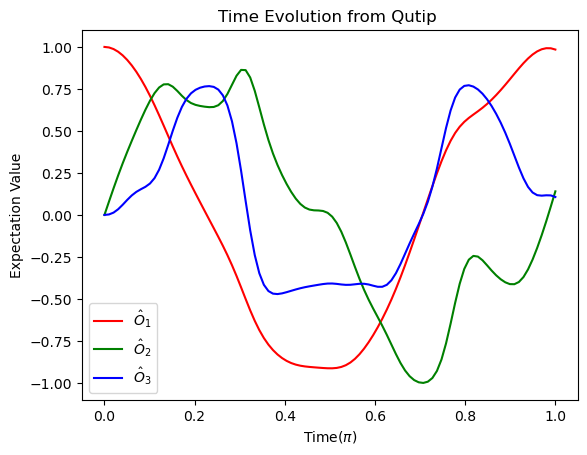

In [26]:
tfinal      = 2.52*np.pi
N           = 100
Nedo        = 3

tlist = np.linspace(0.0, tfinal, N)
valor_esperado_data  = data_qubit(O_op,tlist,Field,device="cpu")

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(tlist/tfinal,
             valor_esperado_data[:,i].cpu() ,
             label=fr"$\hat{{O}}_{{{i+1}}}$",
             color=colors[i])
    
plt.xlabel(r'Time($\pi$)')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()

In [27]:
time = tc.linspace(
    0, tfinal, N,
    dtype = tc.float32,
    requires_grad = True).reshape((-1, 1))

X_vector = my.Rede(
    neuronio   = [15,15],
    input_     = 1,
    output_    = 3,
    activation =[mf.SIN(), mf.SIN()])

mixfunn_field = mf.MixFunn(
    N_layers = 2,
    N_neuro = 1,
    second_order_function = True)

opt = tc.optim.Adam(list(mixfunn_field.parameters())+list(X_vector.parameters()), lr=0.1, betas=(0.9,0.9))

JZ = 1e0
JY = 0e0
epocas  = 3000

100%|██████████| 3000/3000 [00:11<00:00, 268.71it/s]


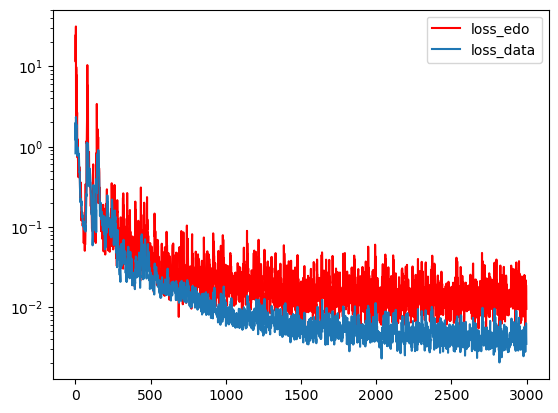

In [28]:
LOSS    = []
LOSS1   = []
LOSS2   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y   = X_vector(time)    # [N,3]
    JX  = mixfunn_field(time)   # [N,1]

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]):
        dX_dt.append(
            tc.autograd.grad(
                outputs = y[:, i],
                inputs = time,
                grad_outputs = tc.ones_like(y[:, i]),
                #retain_graph = True,
                create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
    
    X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    LOSS_edo  = 0
    
    LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
    LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()


    ####### loss data(expected values) #######
    LOSS_data=0    
    LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
    LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
    LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
    LOSS_data = LOSS_data.mean()
    

    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data 

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

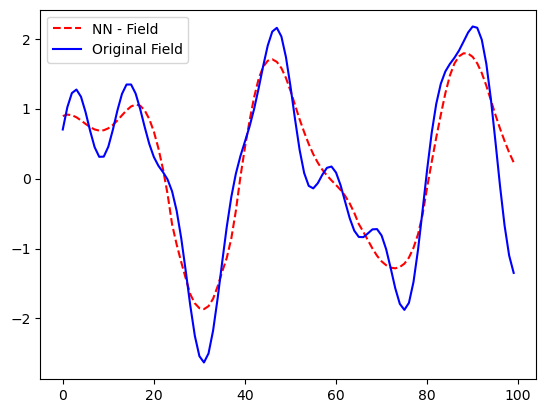

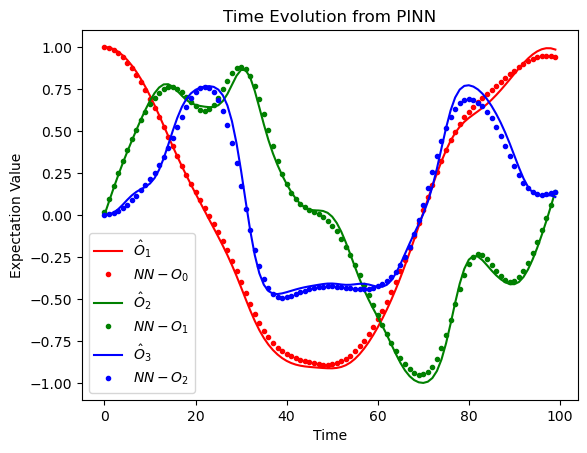

In [29]:
t_points = np.linspace(0,tfinal, N)
JX =  mixfunn_field(time).detach().numpy()

field_original=Field(t_points)
plt.plot(JX,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()


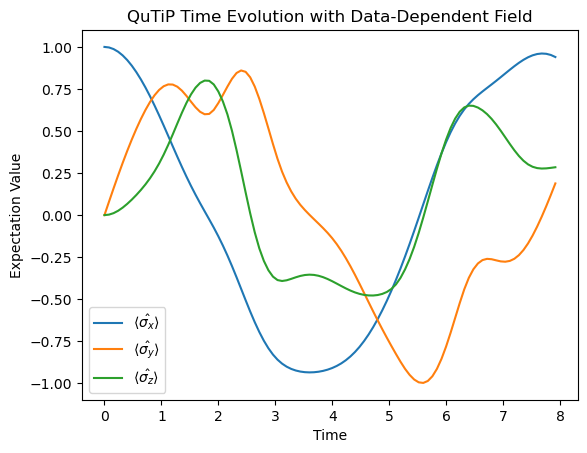

In [30]:
H0 = .5*qt.sigmaz()
H1 = .5*qt.sigmax()
# The full Hamiltonian is defined as a list: 
# H = H0 + f(t) * H1, where f(t) is the field data
H = [H0, [H1, JX.flatten()]] # QuTiP uses cubic spline interpolation for field_data

# (Optional) Define collapse operators for an open system simulation
c_ops = [] # e.g., c_ops = [np.sqrt(gamma) * qt.sigmam()]

# 3. Define the initial state and expectation value operators
theta1  = np.pi/4
phi1    = 0.0 #np.pi/3
psi0    = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))

O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

# 4. Simulate the time evolution
options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
result  = qt.mesolve(H, psi0, t_points, c_ops=c_ops, e_ops=O_op,options=options)

# 5. Plot the results
plt.figure()
plt.plot(t_points, result.expect[0], label=r'$\langle \hat{\sigma_x}\rangle$')
plt.plot(t_points, result.expect[1], label=r'$\langle \hat{\sigma_y}\rangle$')
plt.plot(t_points, result.expect[2], label=r'$\langle \hat{\sigma_z}\rangle$')

plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('QuTiP Time Evolution with Data-Dependent Field')
plt.show()

# prunning 

In [31]:
p = mixfunn_field.layers1.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
p

tensor([[0.1117, 0.0009, 0.0096, 0.0526, 0.0081, 0.0285, 0.0003, 0.1378, 0.0217,
         0.0021, 0.0552, 0.0286, 0.0225, 0.0031, 0.0698, 0.0290, 0.0451, 0.0522,
         0.0250, 0.0007, 0.0214, 0.0122, 0.0038, 0.0472, 0.0070, 0.0451, 0.0109,
         0.0237, 0.0112, 0.0797, 0.0115, 0.0185, 0.0006, 0.0002, 0.0025]])

In [32]:
import torch.nn.utils.prune as prune
prune.l1_unstructured(mixfunn_field.layers1.project1.linear, 'weight', amount=0.1)
prune.l1_unstructured(mixfunn_field.layers1.project1.linear, 'bias', amount=0.1)

prune.l1_unstructured(mixfunn_field.layers2.project1.linear, 'weight', amount=0.1)
prune.l1_unstructured(mixfunn_field.layers2.project1.linear, 'bias', amount=0.1)

p = mixfunn_field.layers1.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
mixfunn_field.layers1.p.data = tc.where(p < 0.01, 0.0, mixfunn_field.layers1.p.data)

p = mixfunn_field.layers1.p.data
L = tc.sum(abs(p))
p = abs(p)/L

values, indices = tc.sort(p)
mask = tc.zeros(indices.shape[1])
for k in range(indices.shape[1]):
    if k > int(0.2*indices.shape[1]):
        mask[indices[0][k]] = 1.0
mixfunn_field.layers1.p.data = mask*mixfunn_field.layers1.p.data
print(mixfunn_field.layers1.p.data)

p = mixfunn_field.layers2.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
mixfunn_field.layers2.p.data = tc.where(p < 0.01, 0.0, mixfunn_field.layers2.p.data)

p = mixfunn_field.layers2.p.data
L = tc.sum(abs(p))
p = abs(p)/L

values, indices = tc.sort(p)
mask2 = tc.zeros(indices.shape[1])
for k in range(indices.shape[1]):
    if k > int(0.2*indices.shape[1]):
        mask2[indices[0][k]] = 1.0
mixfunn_field.layers2.p.data = mask2*mixfunn_field.layers2.p.data
print(mixfunn_field.layers2.p.data)


tensor([[-3.6481,  0.0000,  0.0000,  1.7172,  0.0000,  0.9312,  0.0000,  4.5003,
         -0.7083,  0.0000,  1.8022,  0.9354,  0.7352,  0.0000,  2.2790,  0.9465,
         -1.4722,  1.7061, -0.8173,  0.0000, -0.6987, -0.3977,  0.0000, -1.5423,
          0.0000, -1.4719,  0.3573, -0.7755,  0.3667,  2.6025,  0.3752, -0.6048,
          0.0000,  0.0000,  0.0000]])
tensor([[ 0.0000,  0.0000,  0.7281,  0.8068,  0.0000,  0.0000, -0.3813,  0.0000,
          0.0000,  0.0000,  0.0000, -1.2165,  0.0000,  0.0000,  0.0000, -0.8052,
          0.7395, -0.2225,  0.0000,  0.0000, -0.5326, -0.3660, -2.0099,  0.0000,
          0.3309, -0.6946,  0.3596,  1.2317,  1.1998,  1.0992,  1.1506,  0.5152,
          0.5917,  0.6345,  0.0000]])


100%|██████████| 3000/3000 [00:11<00:00, 272.44it/s]


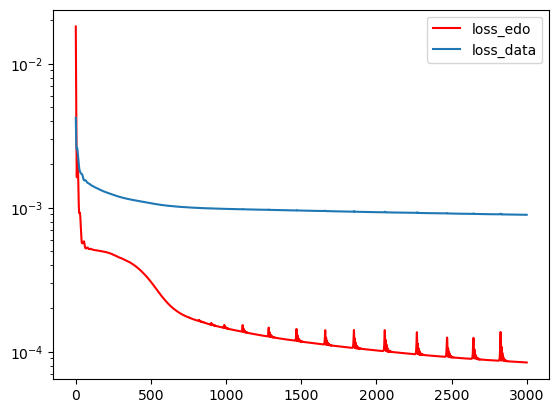

In [33]:
opt = tc.optim.Adam(
    list(mixfunn_field.parameters())+list(X_vector.parameters()),
    lr=0.001)

JZ = 1e0
JY = 0e0

epocas  = 3000

LOSS    = []
LOSS1   = []
LOSS2   = []
for _ in tqdm(range(epocas)):
    # aplicaçao da mascara para os pesos novos
    mixfunn_field.layers1.p.data = mask*mixfunn_field.layers1.p.data
    mixfunn_field.layers2.p.data = mask2*mixfunn_field.layers2.p.data

    ####### Forward pass #######
    y   = X_vector(time)    # [N,3]
    JX  = mixfunn_field(time)   # [N,1]

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]):
        dX_dt.append(
            tc.autograd.grad(
                outputs = y[:, i],
                inputs = time,
                grad_outputs = tc.ones_like(y[:, i]),
                #retain_graph = True,
                create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
    
    X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    LOSS_edo  = 0
    
    LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
    LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()


    ####### loss data(expected values) #######
    LOSS_data=0    
    LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
    LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
    LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
    LOSS_data = LOSS_data.mean()
    

    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data 

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

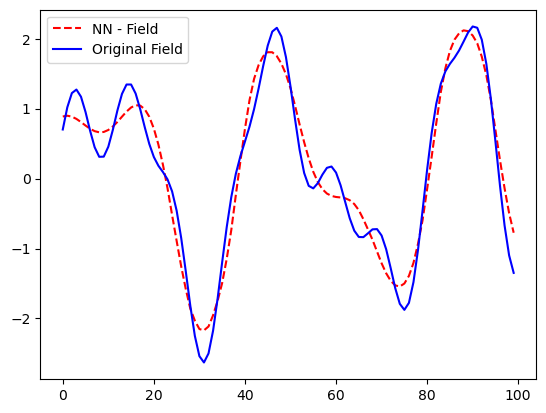

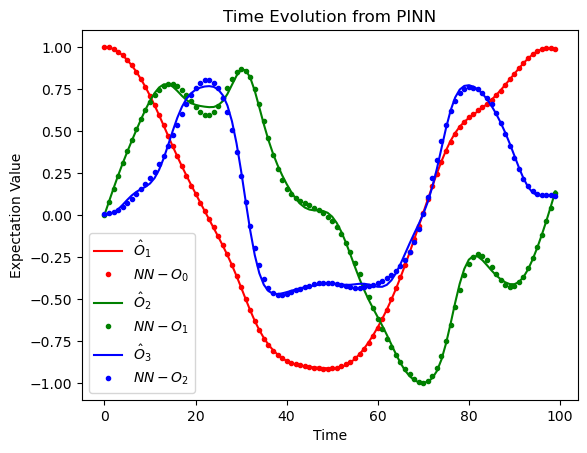

In [34]:
t_points = np.linspace(0,tfinal, N)
JX =  mixfunn_field(time).detach().numpy()

field_original=Field(t_points)
plt.plot(JX,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()


## Expressão analitica

In [35]:
import sympy
from sympy import symbols, Matrix
from sympy import symbols, sin, cos, exp, Abs, sqrt, log, Piecewise

# Define the equivalent SymPy functions
def Sin(x):
    return sin(x)

def Cos(x):
    return cos(x)

def Exp(x):
    return exp(x)

def ExpN(x):
    return exp(-x)

def ExpAbs(x):
    return exp(-0.01 * Abs(x))

def ExpAbsP(x):
    return exp(0.01 * Abs(x))

def Sqrt(x):
    #Approximation of square root to avoid instability
    relu = Piecewise((x, x > 0), (0, True))  # ReLU equivalent
    return sqrt(0.01 + relu)

def Log(x):
    #Approximation of log to avoid instability
    relu = Piecewise((x, x > 0), (0, True))  # ReLU equivalent
    return log(0.1 + relu)

def Id(x):
    return x

# Create the list of symbolic functions
functions = [Sin, Cos, ExpAbs, ExpAbsP, Sqrt, Log, Id]

# functions = [Sin, Cos, Id]

In [36]:
mixfunn_field.layers1.p.data

tensor([[-3.7077e+00,  7.5879e-05,  3.0149e-03,  1.6999e+00, -1.4272e-02,
          6.7267e-01,  0.0000e+00,  4.5850e+00, -7.2506e-01,  6.8566e-02,
          1.8492e+00,  9.8244e-01,  6.8816e-01, -2.9466e-05,  2.5274e+00,
          7.3824e-01, -1.6905e+00,  1.4889e+00, -6.0003e-01, -6.1862e-05,
         -6.9695e-01, -4.0832e-01, -3.6347e-07, -1.5321e+00, -3.2027e-05,
         -1.4865e+00,  3.4306e-01, -7.6124e-01,  2.4224e-01,  2.5889e+00,
          3.8880e-01, -7.3992e-01,  1.7709e-05, -6.6705e-05,  8.1177e-05]])

In [37]:
mixfunn_field.layers2.p.data

tensor([[-1.7452e-02, -6.6749e-07,  7.2571e-01,  8.0212e-01, -4.6427e-03,
          1.1670e-01, -4.0682e-01, -3.0300e-02,  2.9742e-01,  6.4486e-02,
          4.4801e-02, -1.1676e+00,  1.4476e-05,  2.1356e-05,  1.0213e-04,
         -7.9923e-01,  7.5029e-01, -2.0554e-01,  7.2522e-05,  6.3826e-05,
         -5.1828e-01, -3.5107e-01, -1.9937e+00,  1.1142e-07,  2.7452e-01,
         -7.0155e-01,  3.5407e-01,  1.2217e+00,  1.1581e+00,  1.0946e+00,
          1.1407e+00,  4.7290e-01,  6.0161e-01,  6.7685e-01, -9.3725e-06]])

In [ ]:
#(optional) prune parameters
# prune.l1_unstructured(mixfunn_field.layers.project1.linear, 'weight', amount=0.01)

p = mixfunn_field.layers1.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
mixfunn_field.layers1.p.data = tc.where(p < 0.01, 0.0, mixfunn_field.layers1.p.data)

p2 = mixfunn_field.layers2.p.data
L = tc.sum(tc.abs(p2))
p2 = tc.abs(p2)/L
mixfunn_field.layers2.p.data = tc.where(p2 < 0.01, 0.0, mixfunn_field.layers2.p.data)

# Define the symbols for the input
t = symbols('t')

# Define the input vector
inputs = Matrix([t])

#If second-order in the input, append the product between the inputs
# if mixfunn_field.layers1.second_order:
#     inputs = Matrix.vstack(inputs, Matrix([t]))
inputs-1.7452e-02, -6.6749e-07,  7.2571e-01,  8.0212e-01, -4.6427e-03,
          1.1670e-01, -4.0682e-01, -3.0300e-02,  2.9742e-01,  6.4486e-02,
          4.4801e-02, -1.1676e+00,  1.4476e-05,  2.1356e-05,  1.0213e-04,
         -7.9923e-01,  7.5029e-01, -2.0554e-01,  7.2522e-05,  6.3826e-05,
         -5.1828e-01, -3.5107e-01, -1.9937e+00,  1.1142e-07,  2.7452e-01,
         -7.0155e-01,  3.5407e-01,  1.2217e+00,  1.1581e+00,  1.0946e+00,
          1.1407e+00,  4.7290e-01,  6.0161e-01,  6.7685e-01, -9.3725e-06

Matrix([[t]])

Argumentos das funçoes 

In [39]:
w = mixfunn_field.layers1.project1.linear.weight.data.cpu().numpy()
b = mixfunn_field.layers1.project1.linear.bias.data.cpu().numpy().reshape((w.shape[0], 1))

result = (w @ inputs) + b
result = result.reshape(mixfunn_field.layers1.n_out, len(functions))
result.T

Matrix([
[  2.15634*t + 2.41752],
[   1.16932*t + 3.4465],
[ -9.20066*t - 8.74247],
[ 1.13222*t - 0.168624],
[-0.437374*t - 0.77134],
[  3.33854 - 1.50782*t],
[                    0]])

In [40]:
# w = mixfunn_field.layers2.project1.linear.weight.data.cpu().numpy()
# b = mixfunn_field.layers2.project1.linear.bias.data.cpu().numpy().reshape((w.shape[0], 1))

# result = (w @ result) + b
# result = result.reshape(mixfunn_field.layers2.n_out, len(functions))
# result.T

Aplicando a funçao de ativaçao 

In [ ]:
# Apply each function to the result vector
result2 = Matrix(
    [[functions[i](elem) 
         for elem in result[:, i]] 
            for i in range(len(functions))
     ]
    )
result2

Matrix([
[                                                            sin(2.15634*t + 2.41752)],
[                                                             cos(1.16932*t + 3.4465)],
[                                                 exp(-0.01*Abs(9.20066*t + 8.74247))],
[                                                 exp(0.01*Abs(1.13222*t - 0.168624))],
[sqrt(Piecewise((-0.437374*t - 0.77134, 0.437374*t + 0.77134 < 0), (0, True)) + 0.01)],
[     log(Piecewise((3.33854 - 1.50782*t, 1.50782*t - 3.33854 < 0), (0, True)) + 0.1)],
[                                                                                   0]])

In [42]:
mixfunn_field.layers1.p

Parameter containing:
tensor([[-3.7077,  0.0000,  0.0000,  1.6999,  0.0000,  0.6727,  0.0000,  4.5850,
         -0.7251,  0.0000,  1.8492,  0.9824,  0.6882,  0.0000,  2.5274,  0.7382,
         -1.6905,  1.4889, -0.6000,  0.0000, -0.6970, -0.4083,  0.0000, -1.5321,
          0.0000, -1.4865,  0.3431, -0.7612,  0.0000,  2.5889,  0.3888, -0.7399,
          0.0000,  0.0000,  0.0000]], requires_grad=True)

In [43]:
p* (np.array(result2))

TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [ ]:
p = mixfunn_field.layers1.p.data
p = p.detach().cpu().numpy().T.round(2) #arrendondar para 2 casas decimais

result3 = Matrix(p * (np.array(result2)))
result3

ValueError: operands could not be broadcast together with shapes (35,7) (7,7) 

In [ ]:
result4 = Matrix([sum(result3.col(i)) for i in range(result3.cols)])
final_expression = result4[0]
final_expression

In [ ]:
f_numeric = sympy.lambdify(t, final_expression, "numpy")
field_value = f_numeric(time.detach().cpu().numpy().flatten())
plt.plot(time.detach().cpu().numpy().flatten(), field_value, label="Final Expression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
f_numeric = sympy.lambdify(t, final_expression, "numpy")
time = tc.linspace(0, tfinal*2, N)
field_value = f_numeric(time.detach().cpu().numpy().flatten())
plt.plot(time.detach().cpu().numpy().flatten(), field_value, label="Final Expression")
plt.legend()
plt.grid(True)
plt.show()